In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


IMPORT LIBRARY

In [ ]:
# IMPORT LIBRARY
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
from collections import Counter

MENGAMBIL DATASET DARI GDRIVE DAN MENAMPILKANNYA (DATA UNDERSTANDING)

In [ ]:
# LOAD DATA & VISUALISASI DATA
# Membaca dataset
df = pd.read_csv('/content/drive/MyDrive/Skripsi/StressLevelDataset.csv', sep=';')

# Menampilkan seluruh data
print("Seluruh Data:")
display(df)

Seluruh Data:


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,11,17,0,14,3,1,3,2,2,2,...,3,2,2,2,3,3,2,3,3,1
1096,9,12,0,8,0,3,0,0,0,1,...,4,0,1,1,1,1,3,4,3,2
1097,4,26,0,3,1,2,5,2,2,3,...,4,5,1,4,1,3,1,2,1,0
1098,21,0,1,19,5,3,1,4,3,1,...,1,2,5,1,4,1,4,4,4,2


CEK DUPLIKASI DATA

In [ ]:
df.duplicated().sum()

np.int64(0)

CEK MISSING VALUE

In [ ]:
df.isnull().sum()

,0
anxiety_level,0
self_esteem,0
mental_health_history,0
depression,0
headache,0
blood_pressure,0
sleep_quality,0
breathing_problem,0
noise_level,0
living_conditions,0


ANALISA KORELASI FITUR (CORRELATION MATRIX)

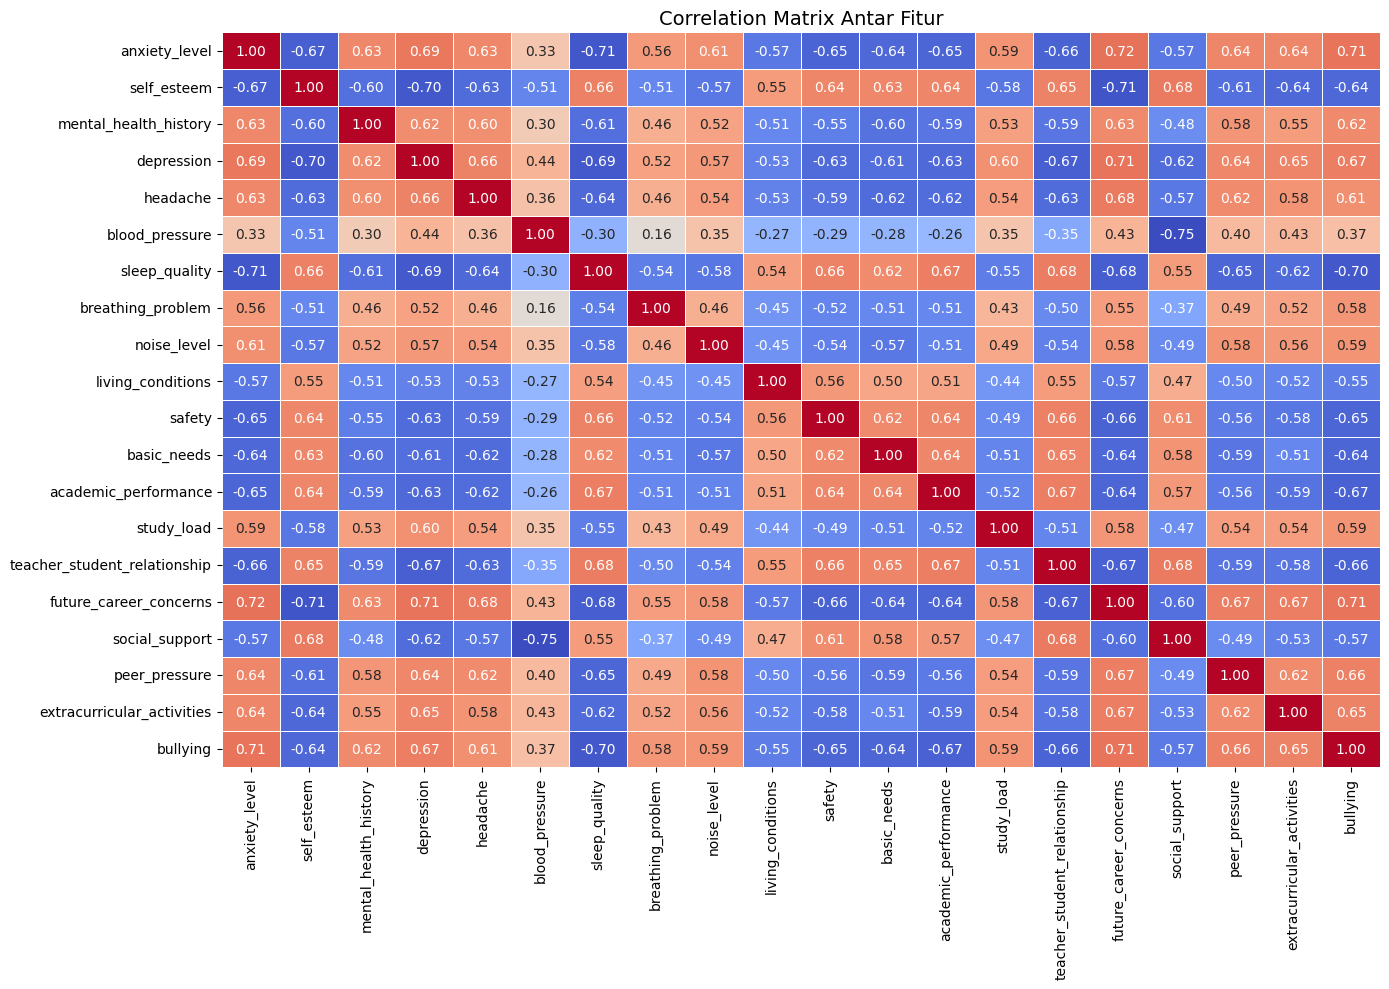

,Feature 1,Feature 2,Correlation


In [ ]:
# Memisahkan Fitur dan Target
# Asumsikan dataset sudah bersih
X = df.drop(columns=['stress_level'])
y = df['stress_level']

# Hitung Matriks Korelasi
corr_matrix = X.corr(method='pearson')

# Visualisasi Heatmap Korelasi
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,              # menampilkan angka di setiap sel
    fmt=".2f",               # 2 angka desimal
    cmap="coolwarm",
    linewidths=0.5,
    cbar=False               # menghilangkan colorbar di samping
)

plt.title("Correlation Matrix Antar Fitur", fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Identifikasi Fitur yang Sangat Berkorelasi
threshold = 0.8
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) >= threshold:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_value
            ))

high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=['Feature 1', 'Feature 2', 'Correlation']
)

high_corr_df

SELEKSI FITUR / VARIABEL

In [ ]:
# Daftar fitur yang dihapus karena redundansi informasi
features_to_drop = [
    'mental_health_history',             # Riwayat kesehatan mental, bukan kondisi psikologis saat ini
    'sleep_quality',                      # Sangat berkorelasi dengan anxiety_level dan depression
    'future_career_concerns',             # Dampak dari kondisi psikologis, redundan dengan anxiety/depression
    'peer_pressure',                       # Mengukur tekanan sosial yang serupa dengan bullying
    'living_conditions'                     # Tumpang tindih dengan basic_needs dan safety
]

# Seleksi Variabel
df_selected = df.drop(columns=features_to_drop)

# Verifikasi Hasil Seleksi
print("Jumlah fitur sebelum seleksi:", df.shape[1] - 1)
print("Jumlah fitur setelah seleksi:", df_selected.shape[1] - 1)

print("\nKolom setelah seleksi:")
for col in df_selected.columns:
    print("-", col)

# Menyimpan Dataset Hasil Seleksi
save_path = "/content/drive/MyDrive/Skripsi/dataset_setelah_seleksi_variabel.csv"
df_selected.to_csv(save_path, index=False)

print("Dataset disimpan di:", save_path)

# Menampilkan Fitur yang Dihapus
removed_features = set(df.columns) - set(df_selected.columns)
print("Fitur yang dihapus:")
for f in removed_features:
    print("-", f)

Jumlah fitur sebelum seleksi: 20
Jumlah fitur setelah seleksi: 15

Kolom setelah seleksi:
- anxiety_level
- self_esteem
- depression
- headache
- blood_pressure
- breathing_problem
- noise_level
- safety
- basic_needs
- academic_performance
- study_load
- teacher_student_relationship
- social_support
- extracurricular_activities
- bullying
- stress_level
Dataset disimpan di: /content/drive/MyDrive/Skripsi/dataset_setelah_seleksi_variabel.csv
Fitur yang dihapus:
- peer_pressure
- living_conditions
- mental_health_history
- sleep_quality
- future_career_concerns


SPLITTING DATA (PEMBAGIAN DATA TRAINING DAN TESTING)

In [ ]:
# Memisahkan fitur (X) dan target (y)
X = df_selected.drop(columns=['stress_level'])
y = df_selected['stress_level']

# Daftar skenario split
split_scenarios = [
    (0.30, "70:30"),
    (0.25, "75:25"),
    (0.22, "78:22"),
    (0.20, "80:20"),
    (0.17, "83:17"),
    (0.13, "87:13")
]

split_results = []

for test_size, label in split_scenarios:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

    # Sort the distribution dictionaries by key
    dist_train = dict(y_train.value_counts())
    dist_test = dict(y_test.value_counts())

    sorted_dist_train = {k: dist_train[k] for k in sorted(dist_train)}
    sorted_dist_test = {k: dist_test[k] for k in sorted(dist_test)}

    split_results.append({
        "Skenario Split": label,
        "Training (%)": int((1 - test_size) * 100),
        "Testing (%)": int(test_size * 100),
        "Jumlah Data Training": X_train.shape[0],
        "Jumlah Data Testing": X_test.shape[0],
        "Distribusi Training": sorted_dist_train,
        "Distribusi Testing": sorted_dist_test
    })

# Tampilkan hasil
split_df = pd.DataFrame(split_results)
split_df

,Skenario Split,Training (%),Testing (%),Jumlah Data Training,Jumlah Data Testing,Distribusi Training,Distribusi Testing
0,70:30,70,30,770,330,"{0: 261, 1: 251, 2: 258}","{0: 112, 1: 107, 2: 111}"
1,75:25,75,25,825,275,"{0: 280, 1: 268, 2: 277}","{0: 93, 1: 90, 2: 92}"
2,78:22,78,22,858,242,"{0: 291, 1: 279, 2: 288}","{0: 82, 1: 79, 2: 81}"
3,80:20,80,20,880,220,"{0: 299, 1: 286, 2: 295}","{0: 74, 1: 72, 2: 74}"
4,83:17,83,17,913,187,"{0: 310, 1: 297, 2: 306}","{0: 63, 1: 61, 2: 63}"
5,87:13,87,13,957,143,"{0: 325, 1: 311, 2: 321}","{0: 48, 1: 47, 2: 48}"


PENYEIMBANGAN DATA (SMOTE)

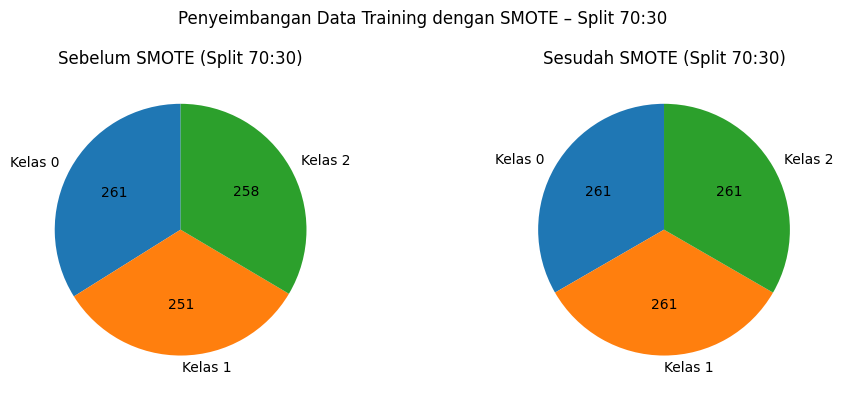

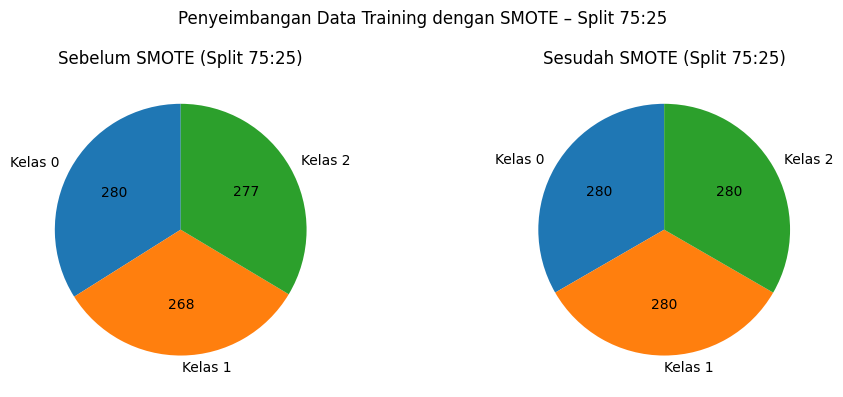

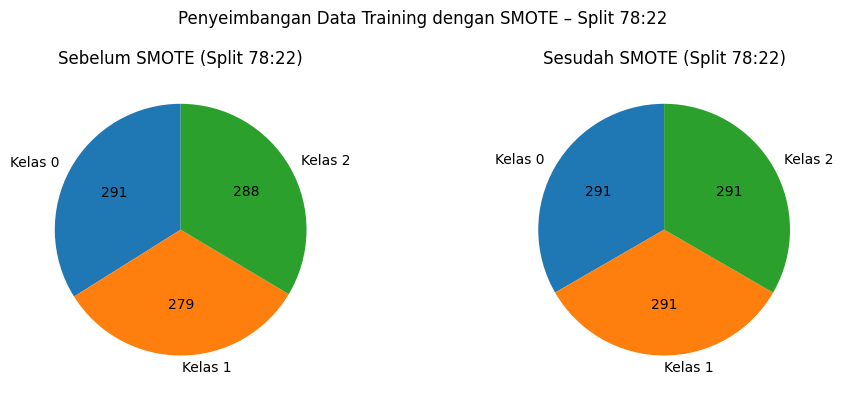

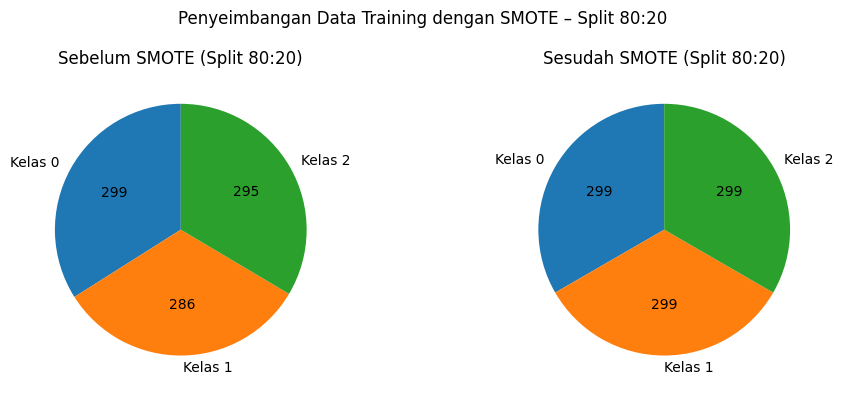

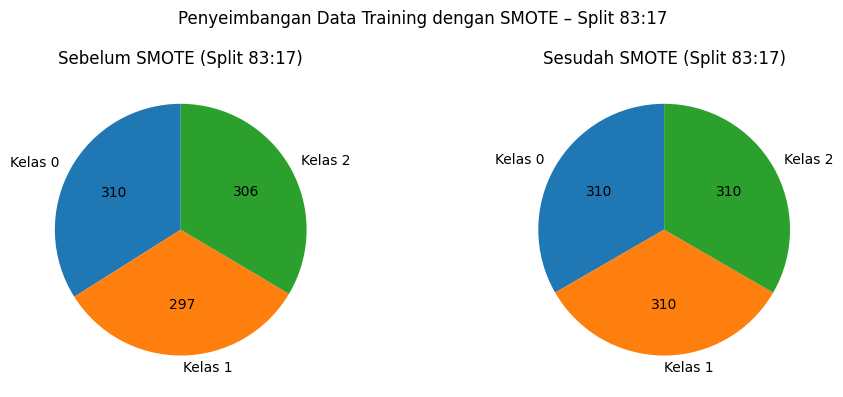

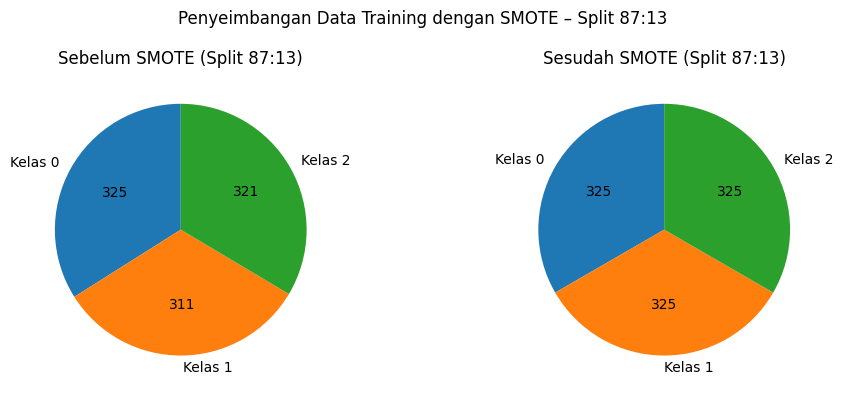

In [ ]:
# Memisahkan fitur dan target
X = df_selected.drop(columns=['stress_level'])
y = df_selected['stress_level']

# Daftar skenario splitting data
split_scenarios = [
    (0.30, "70:30"),
    (0.25, "75:25"),
    (0.22, "78:22"),
    (0.20, "80:20"),
    (0.17, "83:17"),
    (0.13, "87:13")
]

for test_size, label in split_scenarios:
    # SPLITTING DATA
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

    # Distribusi sebelum SMOTE
    dist_before = Counter(y_train)

    # SMOTE (HANYA DATA TRAINING)
    smote = SMOTE(random_state=42)
    X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

    # Distribusi sesudah SMOTE
    dist_after = Counter(y_train_sm)

    # VISUALISASI PIE CHART
    classes = sorted(dist_before.keys())
    labels_cls = [f'Kelas {c}' for c in classes]

    sizes_before = [dist_before[c] for c in classes]
    sizes_after = [dist_after[c] for c in classes]

    plt.figure(figsize=(10, 4))

    # Sebelum SMOTE
    plt.subplot(1, 2, 1)
    plt.pie(
        sizes_before,
        labels=labels_cls,
        autopct=lambda p: int(round(p * sum(sizes_before) / 100)),
        startangle=90
    )
    plt.title(f'Sebelum SMOTE (Split {label})')

    # Sesudah SMOTE
    plt.subplot(1, 2, 2)
    plt.pie(
        sizes_after,
        labels=labels_cls,
        autopct=lambda p: int(round(p * sum(sizes_after) / 100)),
        startangle=90
    )
    plt.title(f'Sesudah SMOTE (Split {label})')

    plt.suptitle(f'Penyeimbangan Data Training dengan SMOTE – Split {label}', fontsize=12)
    plt.tight_layout()
    plt.show()


TRAINING MODEL RANDOM FOREST

In [ ]:
# Memisahkan fitur (X) dan target (y)
X = df_selected.drop(columns=['stress_level'])
y = df_selected['stress_level']

# Daftar skenario splitting data
split_scenarios = [
    (0.30, "70:30"),
    (0.25, "75:25"),
    (0.22, "78:22"),
    (0.20, "80:20"),
    (0.17, "83:17"),
    (0.13, "87:13")
]

trained_models = {}   # menyimpan model tiap skenario

for test_size, label in split_scenarios:
    print(f"\n=== Training Model Random Forest (Split {label}) ===")

    # Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

    # SMOTE (HANYA TRAINING)
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    # Inisialisasi Model Random Forest
    rf_model = RandomForestClassifier(
        n_estimators=100,                       # jumlah pohon
        random_state=42,                        # konsistensi hasil
        max_depth=None,                         # pohon tumbuh optimal
        class_weight=None                       # karena sudah di-SMOTE
    )

    # Melatih Model
    rf_model.fit(X_train_smote, y_train_smote)

    print("Model berhasil dilatih ✔")

    # Simpan model
    trained_models[label] = {
        "model": rf_model,
        "X_test": X_test,
        "y_test": y_test
    }



=== Training Model Random Forest (Split 70:30) ===
Model berhasil dilatih ✔

=== Training Model Random Forest (Split 75:25) ===
Model berhasil dilatih ✔

=== Training Model Random Forest (Split 78:22) ===
Model berhasil dilatih ✔

=== Training Model Random Forest (Split 80:20) ===
Model berhasil dilatih ✔

=== Training Model Random Forest (Split 83:17) ===
Model berhasil dilatih ✔

=== Training Model Random Forest (Split 87:13) ===
Model berhasil dilatih ✔


VISUALISASI SALAH SATU POHON PADA RANDOM FOREST

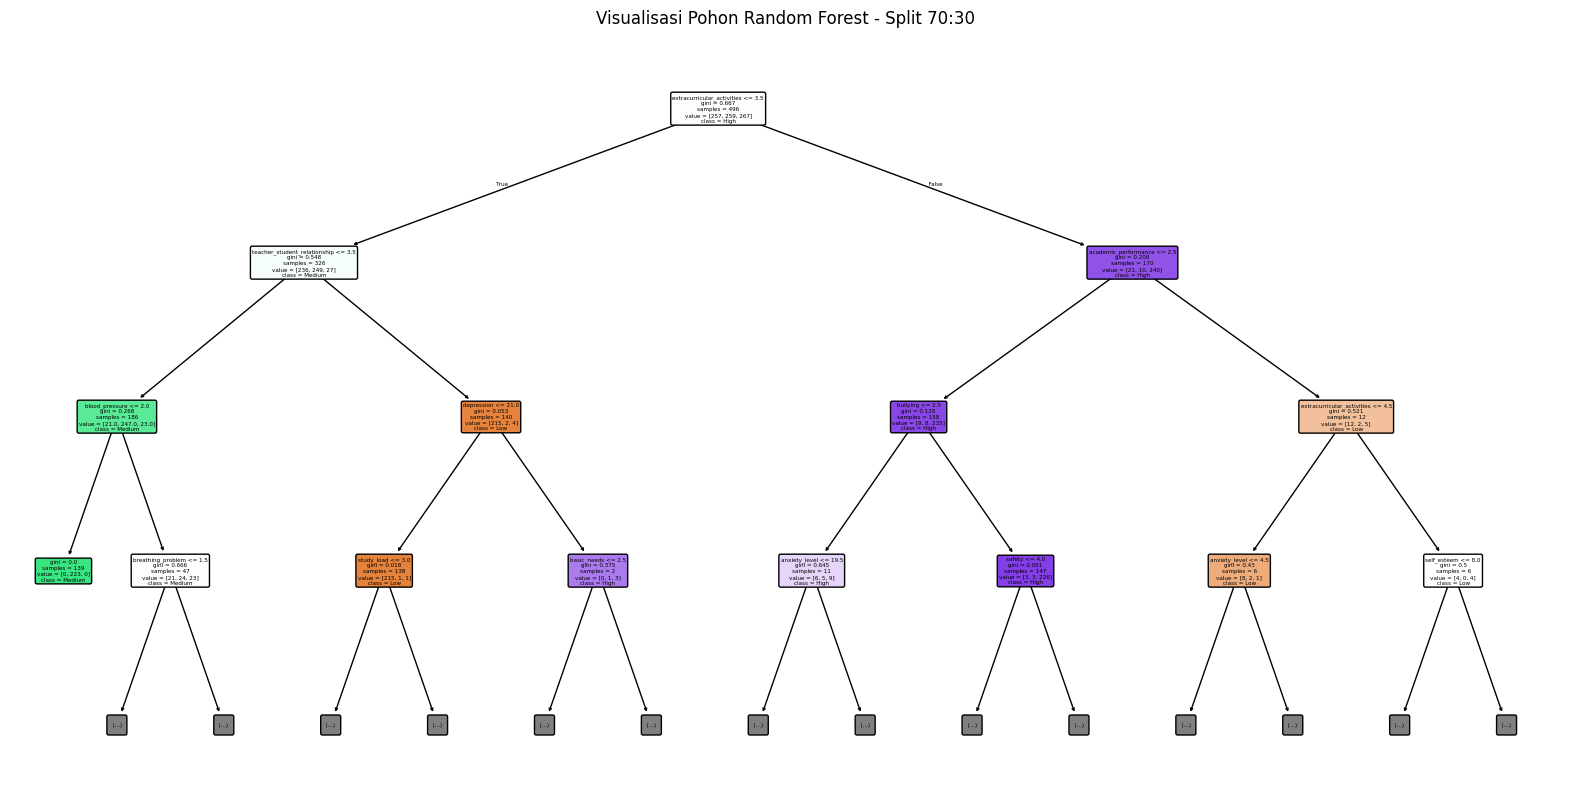

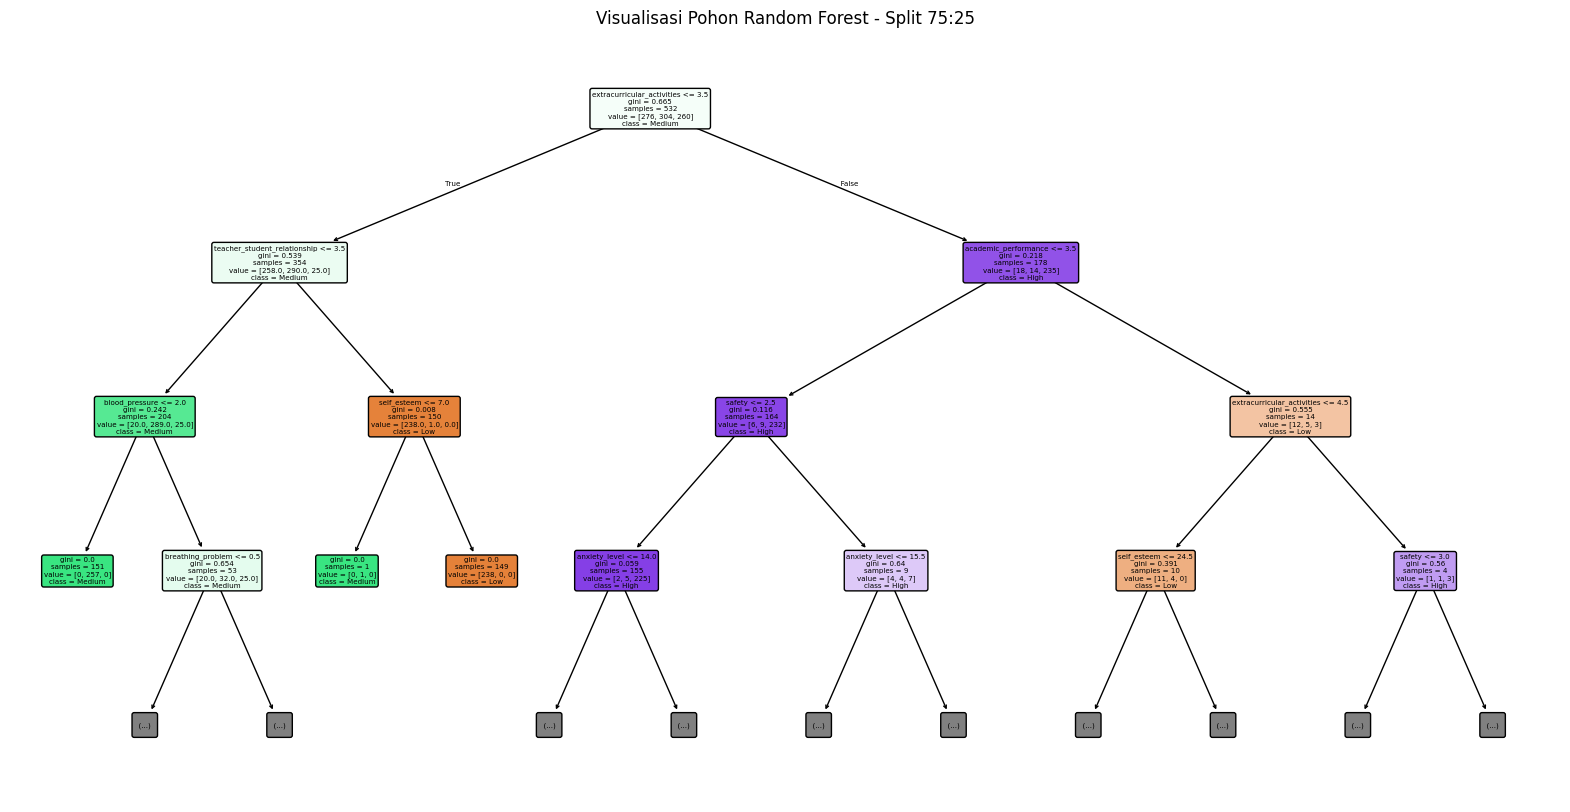

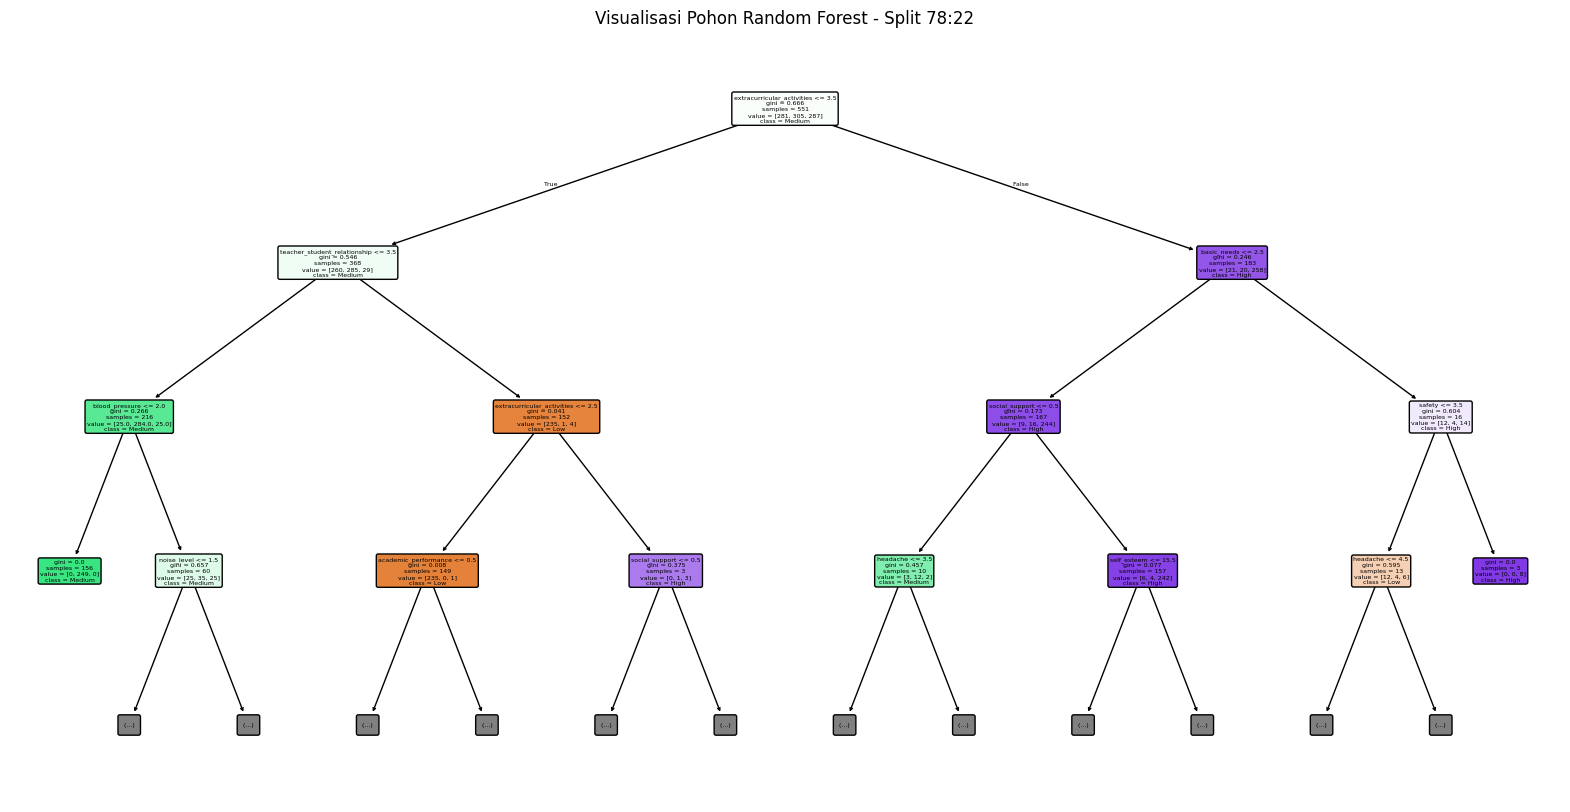

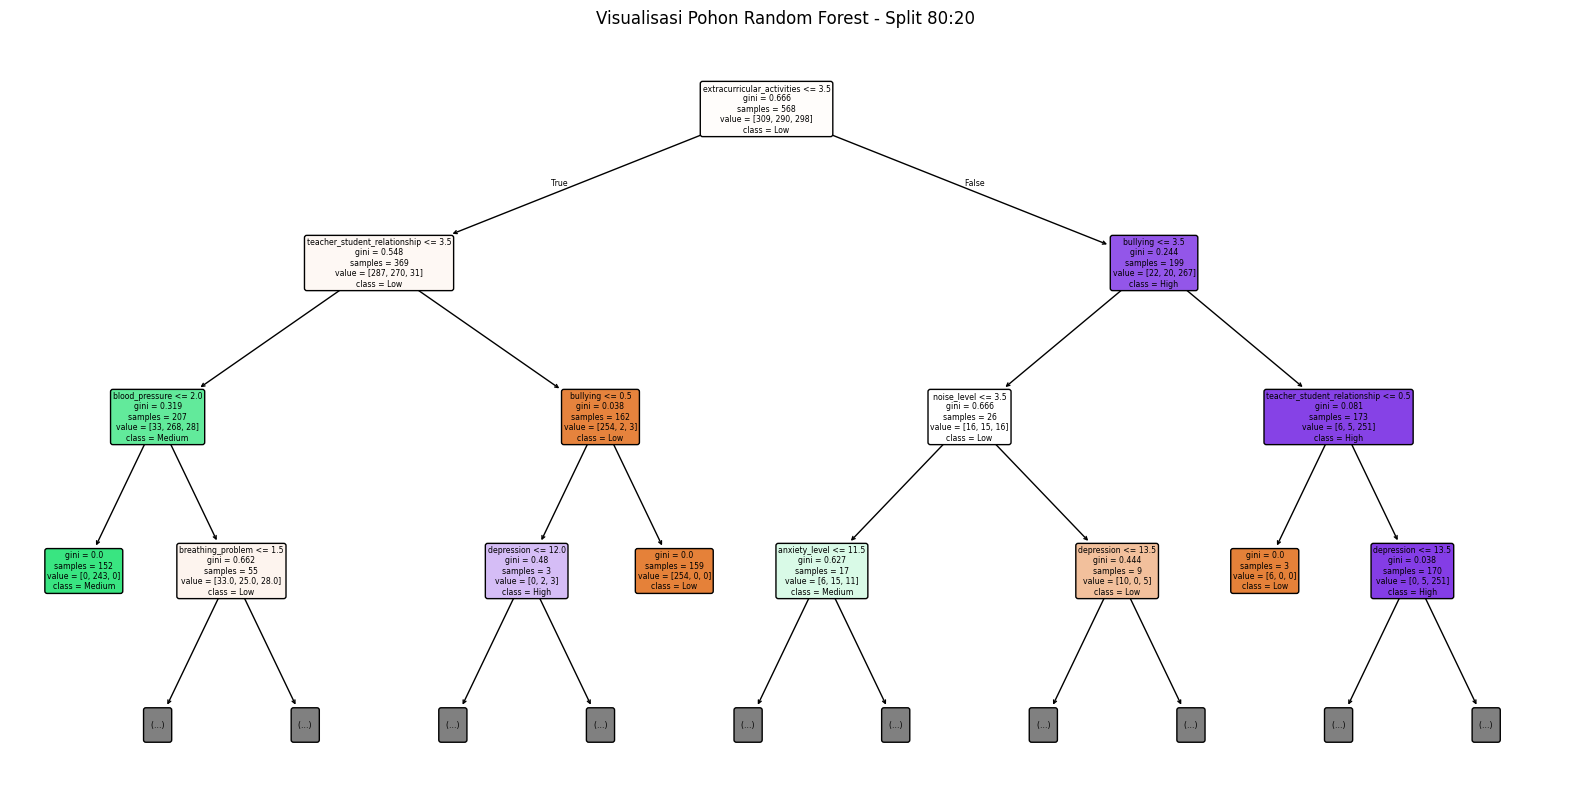

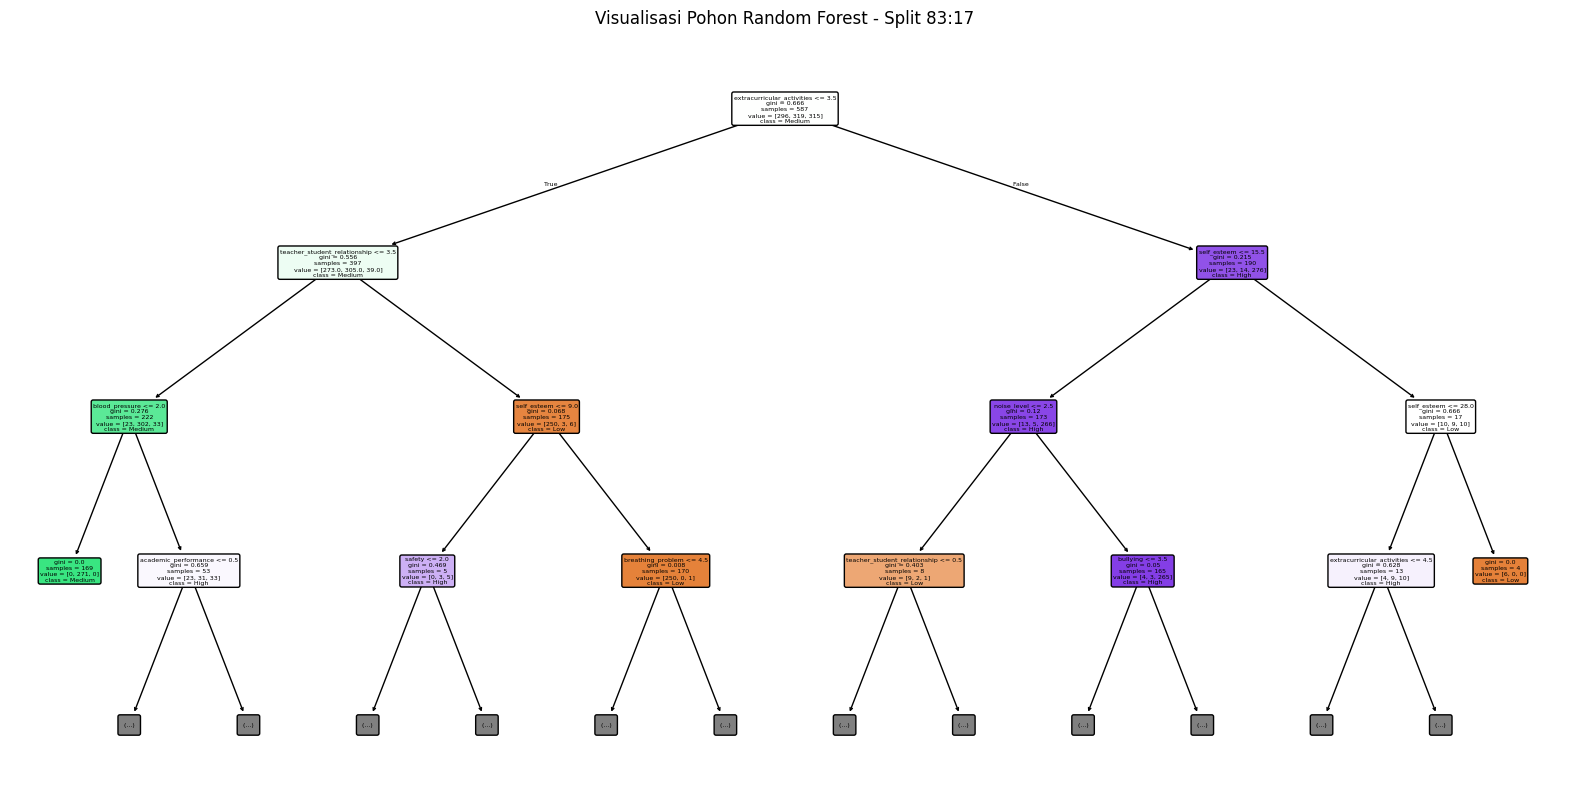

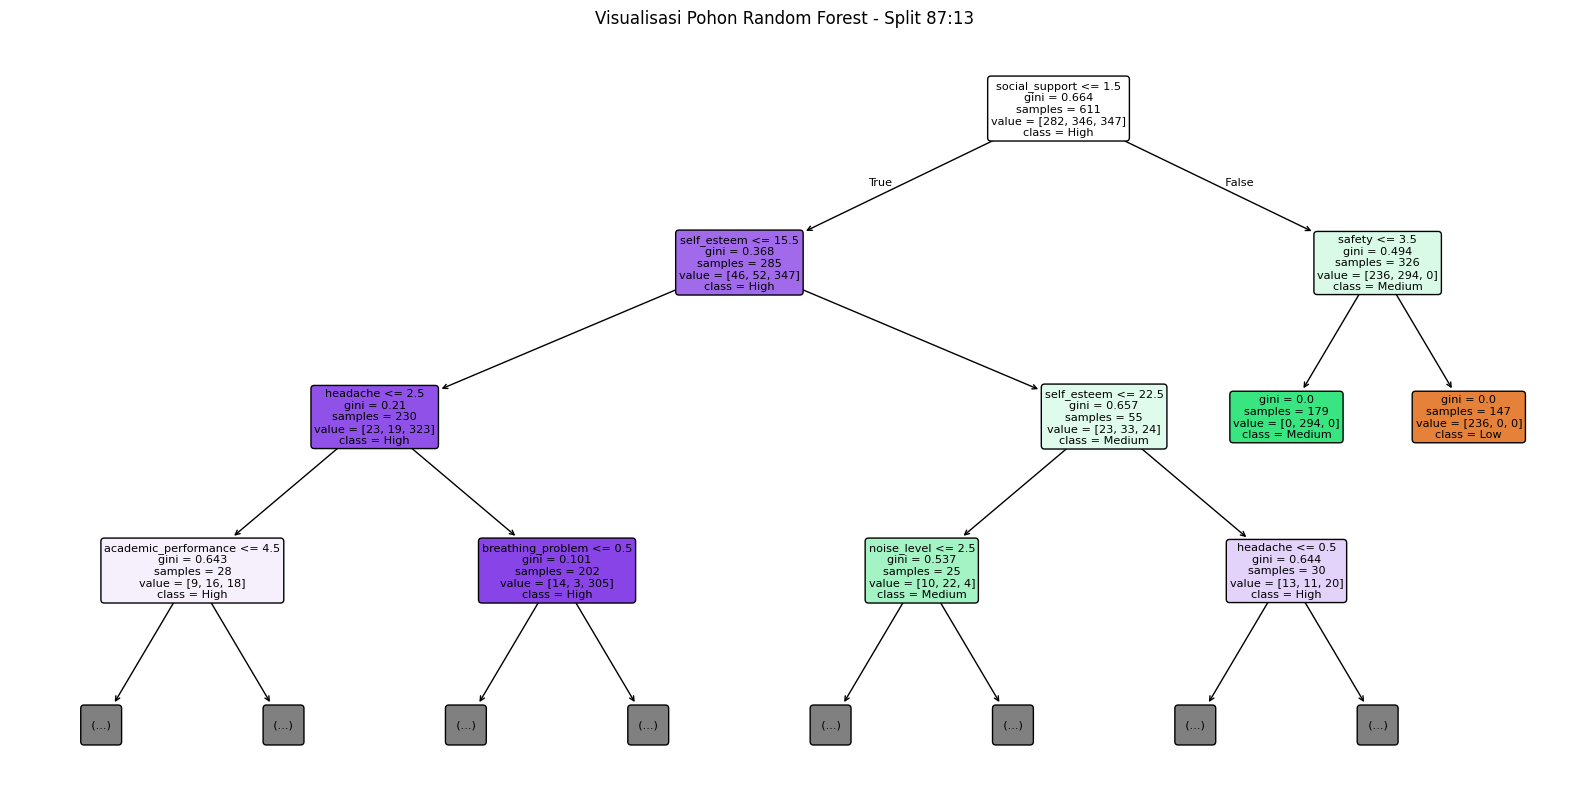

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

for label, data in trained_models.items():
    rf_model = data["model"]

    # Ambil satu pohon (misal pohon pertama)
    tree = rf_model.estimators_[0]

    plt.figure(figsize=(20, 10))
    plot_tree(
        tree,
        feature_names=X.columns,
        class_names=['Low', 'Medium', 'High'],
        filled=True,
        rounded=True,
        max_depth=3
    )
    plt.title(f"Visualisasi Pohon Random Forest - Split {label}")
    plt.show()


EVALUASI MODEL KLASIFIKASI


Evaluasi Model – Split 70:30
Accuracy: 0.8667

Classification Report:
              precision    recall  f1-score   support

         Low       0.86      0.85      0.86       112
      Medium       0.89      0.86      0.88       107
        High       0.85      0.89      0.87       111

    accuracy                           0.87       330
   macro avg       0.87      0.87      0.87       330
weighted avg       0.87      0.87      0.87       330



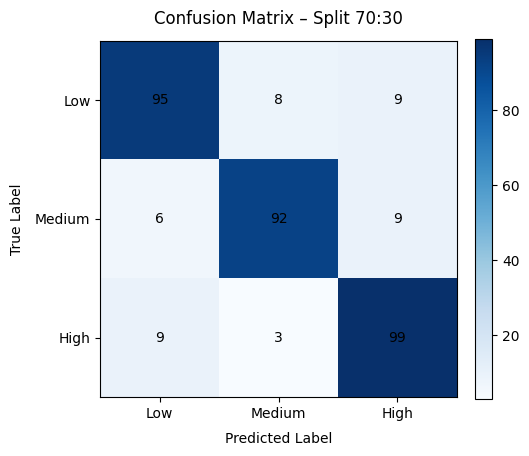


Evaluasi Model – Split 75:25
Accuracy: 0.8655

Classification Report:
              precision    recall  f1-score   support

         Low       0.88      0.83      0.85        93
      Medium       0.89      0.88      0.88        90
        High       0.84      0.89      0.86        92

    accuracy                           0.87       275
   macro avg       0.87      0.87      0.87       275
weighted avg       0.87      0.87      0.87       275



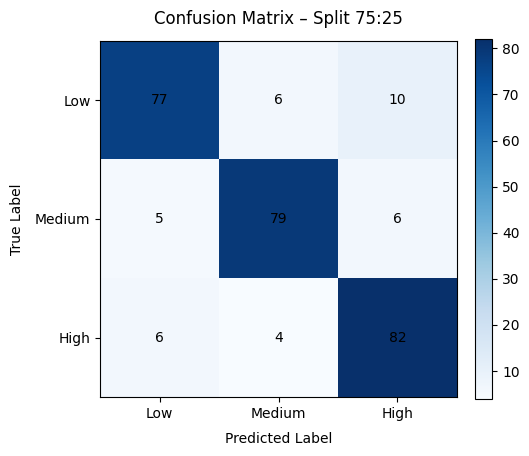


Evaluasi Model – Split 78:22
Accuracy: 0.8926

Classification Report:
              precision    recall  f1-score   support

         Low       0.91      0.88      0.89        82
      Medium       0.89      0.90      0.89        79
        High       0.88      0.90      0.89        81

    accuracy                           0.89       242
   macro avg       0.89      0.89      0.89       242
weighted avg       0.89      0.89      0.89       242



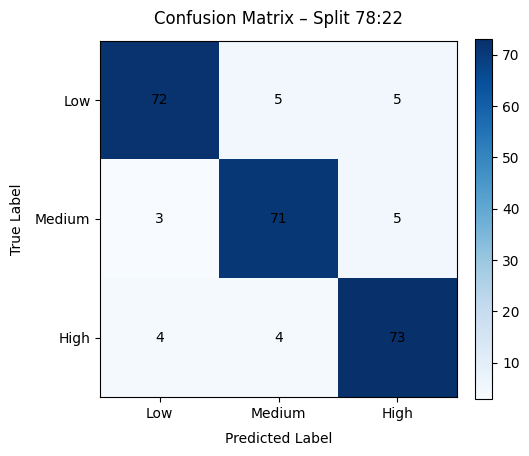


Evaluasi Model – Split 80:20
Accuracy: 0.8955

Classification Report:
              precision    recall  f1-score   support

         Low       0.86      0.86      0.86        74
      Medium       0.96      0.90      0.93        72
        High       0.87      0.92      0.89        74

    accuracy                           0.90       220
   macro avg       0.90      0.90      0.90       220
weighted avg       0.90      0.90      0.90       220



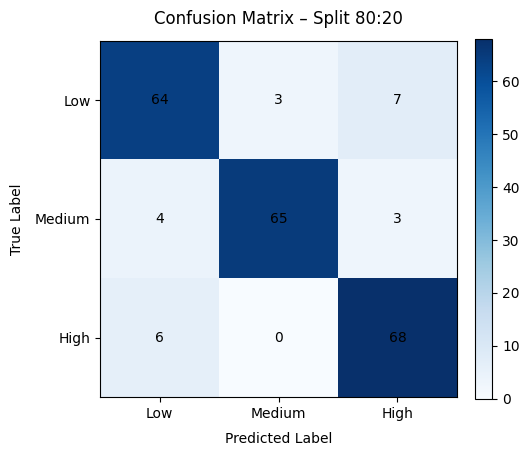


Evaluasi Model – Split 83:17
Accuracy: 0.8556

Classification Report:
              precision    recall  f1-score   support

         Low       0.86      0.81      0.84        63
      Medium       0.87      0.89      0.88        61
        High       0.83      0.87      0.85        63

    accuracy                           0.86       187
   macro avg       0.86      0.86      0.86       187
weighted avg       0.86      0.86      0.86       187



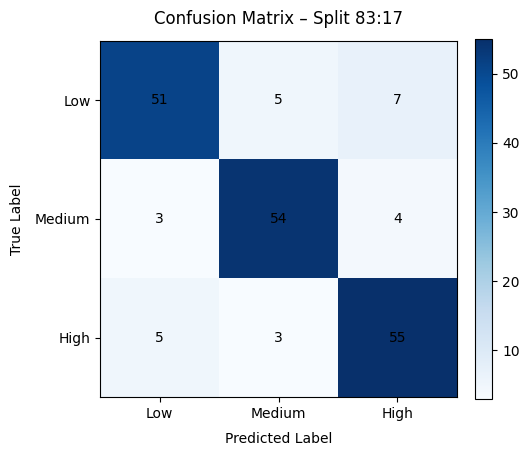


Evaluasi Model – Split 87:13
Accuracy: 0.8741

Classification Report:
              precision    recall  f1-score   support

         Low       0.93      0.83      0.88        48
      Medium       0.87      0.87      0.87        47
        High       0.83      0.92      0.87        48

    accuracy                           0.87       143
   macro avg       0.88      0.87      0.87       143
weighted avg       0.88      0.87      0.87       143



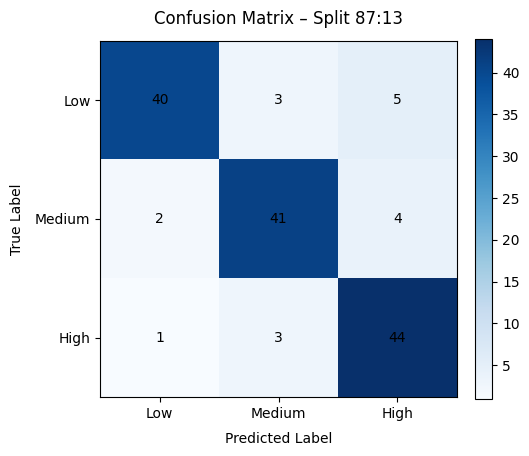

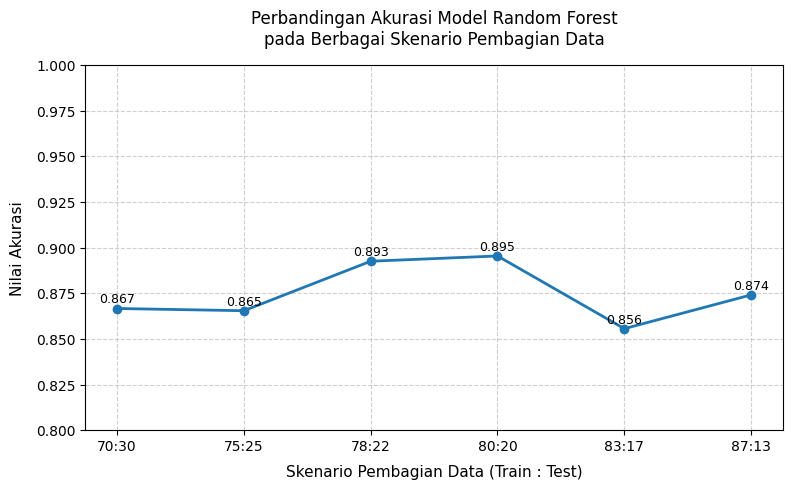

In [ ]:
# MEMISAHKAN FITUR DAN TARGET
X = df_selected.drop(columns=['stress_level'])
y = df_selected['stress_level']

# DAFTAR SKENARIO SPLITTING DATA
split_scenarios = [
    (0.30, "70:30"),
    (0.25, "75:25"),
    (0.22, "78:22"),
    (0.20, "80:20"),
    (0.17, "83:17"),
    (0.13, "87:13")
]

accuracy_results = []
scenario_labels = []

# LOOP EVALUASI
for test_size, label in split_scenarios:
    print("\n==============================")
    print(f"Evaluasi Model – Split {label}")
    print("==============================")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
    rf_model.fit(X_train_smote, y_train_smote)

    y_pred = rf_model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    accuracy_results.append(accuracy)
    scenario_labels.append(label)

    print("Accuracy:", round(accuracy, 4))

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=['Low', 'Medium', 'High']
    ))

    cm = confusion_matrix(y_test, y_pred)

    # CONFUSION MATRIX (TIDAK MEPET)
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix – Split {label}", pad=12)
    plt.colorbar(pad=0.04)

    classes = ['Low', 'Medium', 'High']
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j],
                     ha='center', va='center', fontsize=10)

    plt.xlabel("Predicted Label", labelpad=8)
    plt.ylabel("True Label", labelpad=8)

    plt.tight_layout(pad=2.5)
    plt.show()

# GRAFIK PERBANDINGAN AKURASI
plt.figure(figsize=(9, 5))

plt.plot(
    scenario_labels,
    accuracy_results,
    marker='o',
    linewidth=2
)

plt.title(
    "Perbandingan Akurasi Model Random Forest\npada Berbagai Skenario Pembagian Data",
    fontsize=12,
    pad=15
)
plt.xlabel("Skenario Pembagian Data (Train : Test)", fontsize=11, labelpad=8)
plt.ylabel("Nilai Akurasi", fontsize=11, labelpad=8)

plt.ylim(0.8, 1.0)
plt.grid(True, linestyle='--', alpha=0.6)

for i, acc in enumerate(accuracy_results):
    plt.text(i, acc + 0.003, f"{acc:.3f}", ha='center', fontsize=9)

# JARAK TAMBAHAN AGAR TIDAK MEPET
plt.subplots_adjust(top=0.88, bottom=0.15)

plt.show()


ANALISIS FEATURE IMPORTANCE

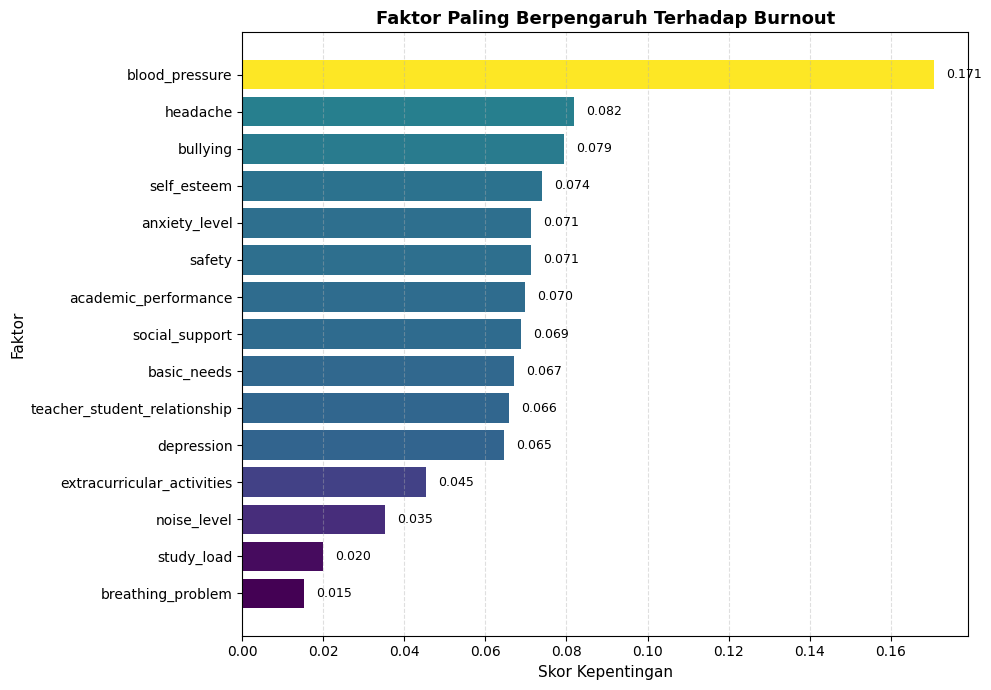

In [ ]:
# Ambil nilai feature importance
importances = rf_model.feature_importances_

# Buat DataFrame
feature_importance_df = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': importances
})

# Urutkan dari yang paling penting
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

feature_importance_df

# Data
features = feature_importance_df['Fitur']
importance = feature_importance_df['Importance']

# Normalisasi nilai importance untuk colormap
norm = plt.Normalize(importance.min(), importance.max())
colors = plt.cm.viridis(norm(importance))  # bisa ganti viridis

plt.figure(figsize=(10, 7))

bars = plt.barh(features, importance, color=colors)

plt.xlabel("Skor Kepentingan", fontsize=11)
plt.ylabel("Faktor", fontsize=11)
plt.title("Faktor Paling Berpengaruh Terhadap Burnout", fontsize=13, weight='bold')

plt.gca().invert_yaxis()

# Grid halus
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Tampilkan nilai di ujung bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.003,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()